In [59]:
import numpy as np
import pandas as pd

In [60]:
ather_stock = r"C:\Users\hp\Downloads\ATHERENERG.NS_1Y_1DAY_FROM_PERPLEXITY.csv"
df = pd.read_csv(ather_stock)
df.head()

,date,open,high,low,close,volume
0,2026-03-09T00:00:00+05:30,653.05,684.35,650.35,681.25,1444166.0
1,2026-03-06T00:00:00+05:30,697.50,697.50,663.75,672.35,752277.0
2,2026-03-05T00:00:00+05:30,701.10,703.55,674.30,682.85,1712935.0
3,2026-03-04T00:00:00+05:30,701.20,703.80,674.30,700.85,1637001.0
4,2026-03-02T00:00:00+05:30,650.75,710.00,650.75,704.30,1950250.0


In [61]:
from datetime import datetime, timedelta

In [62]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [63]:
df.rename(index = {'date':'Date'}, inplace=True)
df.rename(columns = {'open':'Open', 'high':'High', 'low':'Low', 'close' : 'Close', 'volume':'Volume'}, inplace=True)

In [64]:
df.index.name = 'Date'
df

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09 00:00:00+05:30,653.05,684.35,650.35,681.25,1444166.0
2026-03-06 00:00:00+05:30,697.50,697.50,663.75,672.35,752277.0
2026-03-05 00:00:00+05:30,701.10,703.55,674.30,682.85,1712935.0
2026-03-04 00:00:00+05:30,701.20,703.80,674.30,700.85,1637001.0
2026-03-02 00:00:00+05:30,650.75,710.00,650.75,704.30,1950250.0
...,...,...,...,...,...
2025-05-12 00:00:00+05:30,311.15,317.75,307.00,309.55,2114486.0
2025-05-09 00:00:00+05:30,297.85,309.00,295.65,300.20,1481489.0
2025-05-08 00:00:00+05:30,310.00,324.00,301.75,303.90,3680805.0


In [65]:
df.dropna(inplace=True)

In [66]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-09 00:00:00+05:30,653.05,684.35,650.35,681.25,1444166.0
2026-03-06 00:00:00+05:30,697.50,697.50,663.75,672.35,752277.0
2026-03-05 00:00:00+05:30,701.10,703.55,674.30,682.85,1712935.0
2026-03-04 00:00:00+05:30,701.20,703.80,674.30,700.85,1637001.0
2026-03-02 00:00:00+05:30,650.75,710.00,650.75,704.30,1950250.0
...,...,...,...,...,...
2025-05-12 00:00:00+05:30,311.15,317.75,307.00,309.55,2114486.0
2025-05-09 00:00:00+05:30,297.85,309.00,295.65,300.20,1481489.0
2025-05-08 00:00:00+05:30,310.00,324.00,301.75,303.90,3680805.0


In [68]:
return_series = df.pct_change().dropna()
return_series

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-06 00:00:00+05:30,0.068065,0.019215,0.020604,-0.013064,-0.479092
2026-03-05 00:00:00+05:30,0.005161,0.008674,0.015895,0.015617,1.277000
2026-03-04 00:00:00+05:30,0.000143,0.000355,0.000000,0.026360,-0.044330
2026-03-02 00:00:00+05:30,-0.071948,0.008809,-0.034925,0.004923,0.191355
2026-02-27 00:00:00+05:30,0.075682,0.002324,0.055090,0.009300,-0.277423
...,...,...,...,...,...
2025-05-12 00:00:00+05:30,0.005331,0.023514,0.023333,0.022799,0.698185
2025-05-09 00:00:00+05:30,-0.042745,-0.027537,-0.036971,-0.030205,-0.299362
2025-05-08 00:00:00+05:30,0.040792,0.048544,0.020633,0.012325,1.484531


In [69]:
return_arr = return_series.to_numpy()

In [70]:
return_arr

array([[ 6.80652324e-02,  1.92153138e-02,  2.06042900e-02,
        -1.30642202e-02, -4.79092431e-01],
       [ 5.16129032e-03,  8.67383513e-03,  1.58945386e-02,
         1.56168662e-02,  1.27700036e+00],
       [ 1.42633005e-04,  3.55340772e-04,  0.00000000e+00,
         2.63601084e-02, -4.43297615e-02],
       ...,
       [ 4.07923451e-02,  4.85436893e-02,  2.06325047e-02,
         1.23251166e-02,  1.48453077e+00],
       [-6.48387097e-02,  1.77469136e-02, -4.50704225e-02,
         1.99078644e-02,  1.62924089e+00],
       [ 1.31424629e-01,  9.85595148e-03,  3.80010411e-02,
        -2.46814002e-02,  5.50058831e-01]], shape=(210, 5))

In [71]:
cov_matrix = np.cov(return_arr, rowvar=False)
corr_matrix = np.corrcoef(return_arr, rowvar= False)
print("Covariance matrix:\n",cov_matrix)
print("Correlation matrix: \n", corr_matrix)

Covariance matrix:
 [[ 9.67415447e-04  2.86134062e-04  4.37503897e-04  9.82590896e-06
  -6.45466818e-03]
 [ 2.86134062e-04  8.51612356e-04  3.59932755e-04  6.20557087e-04
   1.16616945e-02]
 [ 4.37503897e-04  3.59932755e-04  7.12368508e-04  4.16391296e-04
  -7.01708805e-03]
 [ 9.82590896e-06  6.20557087e-04  4.16391296e-04  8.43776671e-04
   5.58169168e-03]
 [-6.45466818e-03  1.16616945e-02 -7.01708805e-03  5.58169168e-03
   3.88199869e+00]]
Correlation matrix: 
 [[ 1.          0.31524055  0.5270151   0.01087558 -0.105327  ]
 [ 0.31524055  1.          0.46211284  0.73206055  0.20282103]
 [ 0.5270151   0.46211284  1.          0.53707573 -0.13343719]
 [ 0.01087558  0.73206055  0.53707573  1.          0.09752689]
 [-0.105327    0.20282103 -0.13343719  0.09752689  1.        ]]


In [72]:
cols = ['Open', 'High', 'Low', 'Close', 'Volume']

cov_df = pd.DataFrame(cov_matrix, index = cols, columns = cols)
corr_df = pd.DataFrame(corr_matrix, index = cols, columns = cols)
print("Covariance matrix:\n",cov_df)
print("Correlation matrix:\n",corr_df)

Covariance matrix:
             Open      High       Low     Close    Volume
Open    0.000967  0.000286  0.000438  0.000010 -0.006455
High    0.000286  0.000852  0.000360  0.000621  0.011662
Low     0.000438  0.000360  0.000712  0.000416 -0.007017
Close   0.000010  0.000621  0.000416  0.000844  0.005582
Volume -0.006455  0.011662 -0.007017  0.005582  3.881999
Correlation matrix:
             Open      High       Low     Close    Volume
Open    1.000000  0.315241  0.527015  0.010876 -0.105327
High    0.315241  1.000000  0.462113  0.732061  0.202821
Low     0.527015  0.462113  1.000000  0.537076 -0.133437
Close   0.010876  0.732061  0.537076  1.000000  0.097527
Volume -0.105327  0.202821 -0.133437  0.097527  1.000000


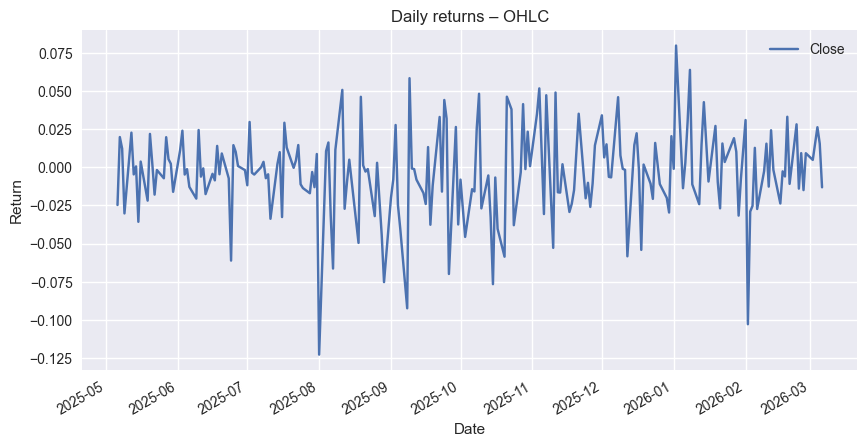

In [73]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(figsize=(10, 5))
return_series[['Close']].plot(ax=ax)

ax.set_title("Daily returns – OHLC")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
fig.autofmt_xdate()
plt.show()



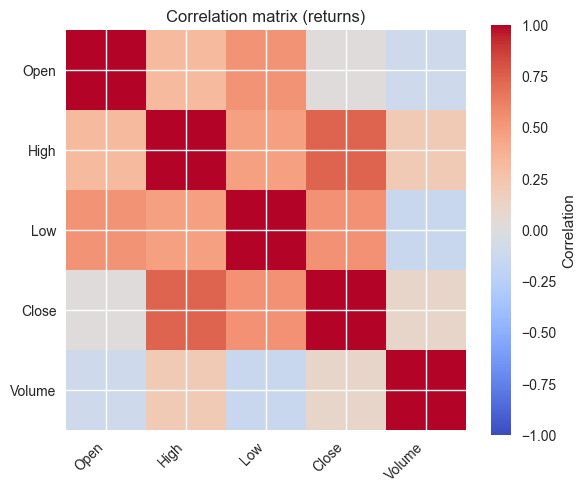

In [74]:
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_df.columns)

ax.set_title("Correlation matrix (returns)")
fig.colorbar(cax, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


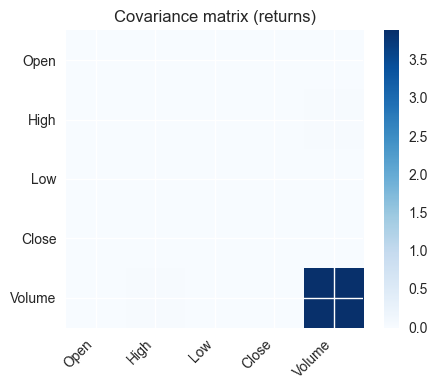

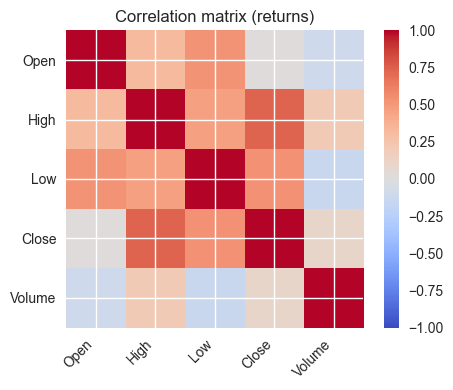

In [75]:
# Covariance matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cov_df.values, cmap="Blues")
ax.set_xticks(range(len(cov_df.columns)))
ax.set_yticks(range(len(cov_df.columns)))
ax.set_xticklabels(cov_df.columns, rotation=45, ha="right")
ax.set_yticklabels(cov_df.columns)
ax.set_title("Covariance matrix (returns)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Correlation matrix
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_df.columns)))
ax.set_yticks(range(len(corr_df.columns)))
ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_df.columns)
ax.set_title("Correlation matrix (returns)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
